In [1]:
# 🔹Clone the repository and move into the project folder
!git clone https://github.com/Lori-in-the-clouds/SIDS_revelation_project.git
%cd SIDS_revelation_project

print("\n" + "="*50)
print("1. REPOSITORY CLONED SUCCESFULLY")
print("="*50 + "\n")

Cloning into 'SIDS_revelation_project'...
remote: Enumerating objects: 3042, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 3042 (delta 51), reused 61 (delta 23), pack-reused 2946 (from 2)
Receiving objects: 100% (3042/3042), 784.89 MiB | 25.89 MiB/s, done.
Resolving deltas: 100% (535/535), done.
Updating files: 100% (84/84), done.
/content/SIDS_revelation_project

1. REPOSITORY CLONED SUCCESFULLY



In [2]:
# 🔹Install dependencies
!pip install --quiet \
    torch torchvision --index-url https://download.pytorch.org/whl/cu118 \
    --extra-index-url https://pypi.org/simple \
    numpy pandas matplotlib opencv-python scikit-learn scipy pillow tqdm requests pytz umap-learn xgboost ultralytics \
    git+https://github.com/KevinMusgrave/pytorch-metric-learning.git

print("\n" + "="*50)
print("2. DEPENDENCIES INSTALLED SUCCESFULLY ")
print("="*50 + "\n")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.9 MB/s eta 0:00:00

2. DEPENDENCIES INSTALLED SUCCESFULLY 



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

3. UPLOAD A VIDEO TO BE ANALYZED



Saving baby_1.mp4 to baby_1.mp4
VIDEO UPLOADED SUCCESFULLY: baby_1.mp4

4. START VIDEO PROCESSING, USING DEVICE cpu


Extracting dataset info from .coco.json file:---------------------------------------------
Dataset contains 4158 valid samples, and labels are {'baby_on_back': 1, 'baby_on_stomach': 2}
------------------------------------------------------------------------------------------

Loading features from .csv----------------------------------------------------------------
Features loaded succesfully, in particular there are 4158 files in the dataset
------------------------------------------------------------------------------------------

Embedding builder initialized successfully------------------------------------------------
Face detection model: 4 (YOLOv8)
Dataset: /content/SIDS_revelation_project/datasets/onback_onstomach_v3
Dataset dimension: 4158
Dataset labels: {'baby_safe': 0, 'baby_unsafe': 1}
-------------------------------------------------------------------------

🎥 Video processing:   0%|          | 0/192 [00:00<?, ?it/s]

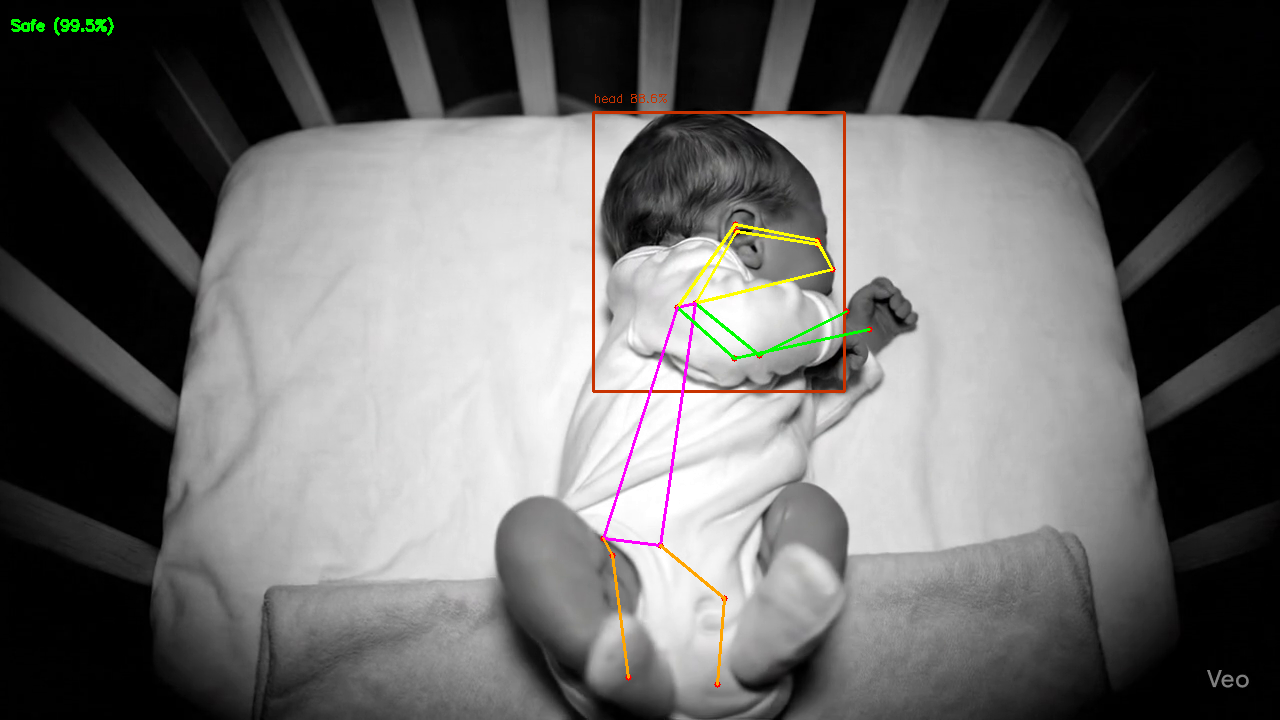

KeyboardInterrupt: 

In [3]:
from google.colab import files
import os
from google.colab.patches import cv2_imshow
import importlib
import main
from libraries import video_utils, embeddings_utils
importlib.reload(video_utils)
importlib.reload(embeddings_utils)
importlib.reload(main)
from main import create_embeddings, process_video_mlp
import torch

# 🔹 Upload video to Colab
print("\n" + "="*50)
print(f"3. UPLOAD A VIDEO TO BE ANALYZED")
print("="*50 + "\n")

uploaded = files.upload()
input_video = list(uploaded.keys())[0]

print(f"VIDEO UPLOADED SUCCESFULLY: {input_video}")

# 🔹 Set PyTorch device
def find_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = find_device()
print("\n" + "="*50)
print(f"4. START VIDEO PROCESSING, USING DEVICE {device}")
print("="*50 + "\n")

# 🔹 Create embeddings and models
project_dir = os.path.join(os.getcwd().split('SIDS_revelation_project')[0], "SIDS_revelation_project")
model_path_pe = os.path.join(project_dir, "models/2.pe_weights/best.pt")
image_dataset_path = os.path.join(project_dir, "datasets/onback_onstomach_v3")
model_path_fd = os.path.join(project_dir, "models/4.fd_weights/best.pt")

model_mlp, emb_builder, clf = create_embeddings(
    project_dir, image_dataset_path, model_path_fd, model_path_pe, device
)

# 🔹 Process video in Colab mode
output_video_path = process_video_mlp(
    input_video_path=input_video,
    builder=emb_builder,
    model_mlp=model_mlp,
    clf=clf,
    use_filters=True,
    show_all_boxes=True,
    show_all_kpt=True,
    show_confidences=True,
    default_fps=20,
    upper_thresh=0.65,
    lower_thresh=0.35,
    device=device,
    colab=True
)

print("\n" + "="*50)
print(f"5. VIDEO PROCESSING COMPLETED SUCCESFULLY, OUTPUT FILE {output_video_path} WILL BE AUTHOMATICALLY DOWNLOADED.")
print("="*50 + "\n")

# 🔹 Automatically download the output video
files.download(output_video_path)
print("🎉 Automatic download completed!")
